In [1]:
# setup environment
import pathlib
import numpy as np
import matplotlib.pyplot as plt

# create higher resolution plots
%config InlineBackend.figure_format = 'retina'

# set directory
filesDir = pathlib.Path('./float32')

In [2]:
# load data
samples = {}
samples['theta']         = np.load(filesDir/'fhn_T200_samplePrior_theta.npy')
samples['spikeRate']     = np.load(filesDir/'fhn_T200_samplePrior_spikeRate.npy')
samples['spikeDuration'] = np.load(filesDir/'fhn_T200_samplePrior_spikeDuration.npy')
n_samples = samples['theta'].shape[0]

print('theta        ', samples['theta'].shape        , samples['theta'].dtype)
print('spikeRate    ', samples['spikeRate'].shape    , samples['spikeRate'].dtype)
print('spikeDuration', samples['spikeDuration'].shape, samples['spikeDuration'].dtype)
print('#samples', n_samples)

theta         (10000, 2) float32
spikeRate     (10000,) float32
spikeDuration (10000,) float32
#samples 10000


In [3]:
def _preprocess_apply_scale(arrays, scale):
    for a in arrays:
        np.add(a, -scale['shift'], out=a)
        np.multiply(a, 1.0/scale['mult'], out=a)

# calculate scaling
Nscale = 4096 # use only a subset of samples for scaling
scale = dict()
for key in ['spikeRate', 'spikeDuration']:
    data_ = samples[key][:Nscale, ...]
    features_min = np.nanmin(data_)
    features_max = np.nanmax(data_)
    features_std = np.nanstd(data_)
    if np.nanmedian(data_) < (features_max - 2.0*features_std): # if max seems too large
        data_ = data_[ data_ < (features_max - features_std) ]
        features_max = np.amax(data_)
    scale[key] = {'shift': features_min, 'mult': (features_max - features_min)}
print(scale)

# apply scaling
samples_scaled = dict()
for key in ['spikeRate', 'spikeDuration']:
    samples_scaled[key] = samples[key].copy()
    _preprocess_apply_scale((samples_scaled[key],), scale[key])

# replace nan values
for key in ['spikeRate', 'spikeDuration']:
    samples_scaled[key] = np.where(np.isnan(samples_scaled[key]), -1.0, samples_scaled[key])

{'spikeRate': {'shift': 65.06506, 'mult': 50.05005}, 'spikeDuration': {'shift': 0.0, 'mult': 8.323077}}


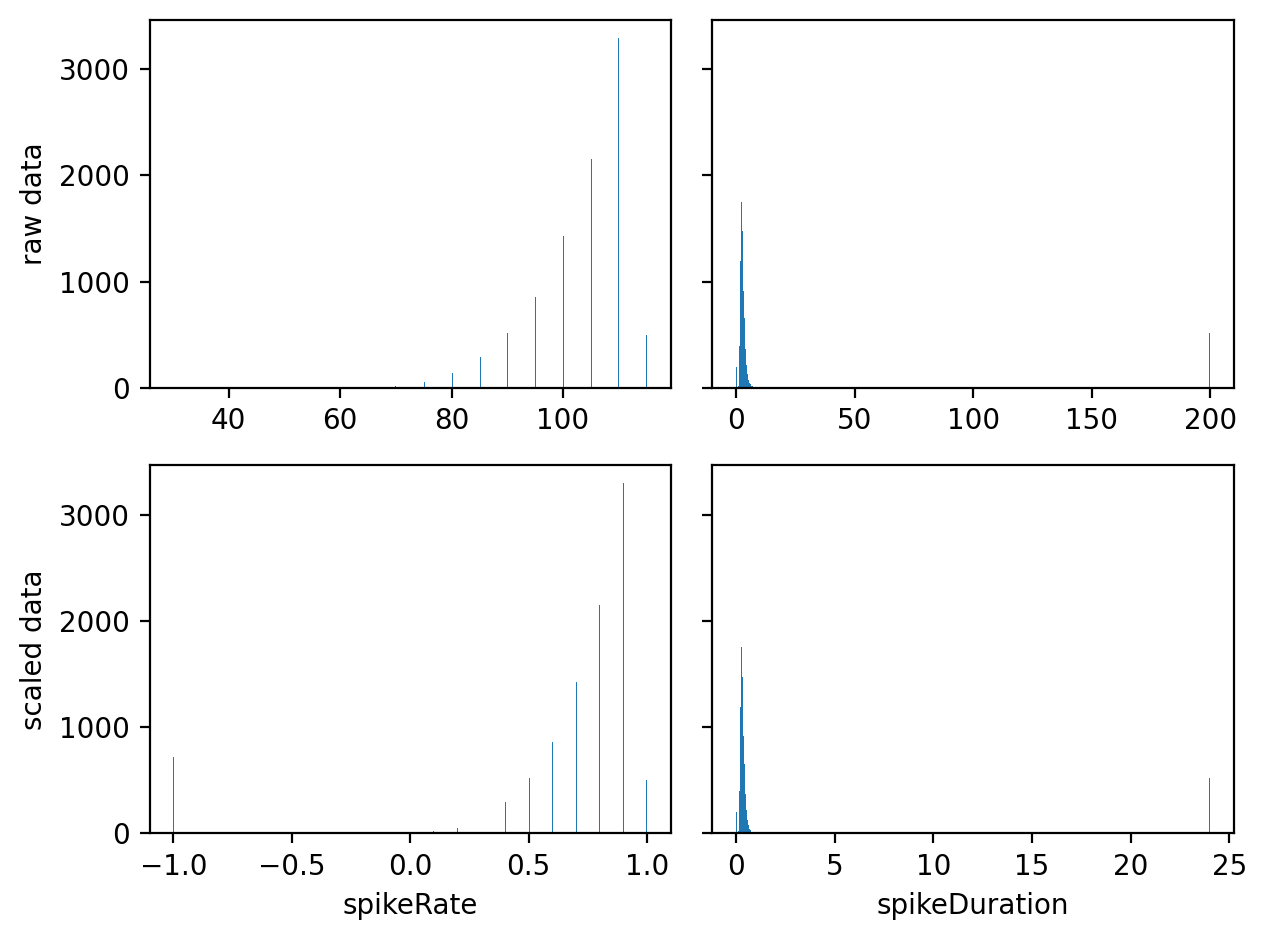

In [4]:
# plot histograms of rate and duration
fig, axs = plt.subplots(2, 2, sharey=True, tight_layout=True)

for i, key in enumerate(['spikeRate', 'spikeDuration']):
    axs[0,i].hist(samples[key], bins=512)
    axs[1,i].hist(samples_scaled[key], bins=512)
    axs[1,i].set_xlabel(key)
    
axs[0,0].set_ylabel('raw data')
axs[1,0].set_ylabel('scaled data')

plt.show()

In [5]:
def _get_slice_positions_from_histogram(data, range, n_bins, relevant_bins_threshold):
    hist, bin_edges = np.histogram(data.flatten(), range=range, bins=n_bins)
    relevant_bin_indices = hist > relevant_bins_threshold
    relevant_bin_edges   = (bin_edges[:-1])[relevant_bin_indices]
    n_relevant_bins      = np.sum(relevant_bin_indices)
    print(f"Number of relevant bins:  {n_relevant_bins}")
    print(f"Range of relevant values: {relevant_bin_edges[0]} ... {relevant_bin_edges[-1]}")
    with np.printoptions(precision=3, suppress=True):
        print('Relevant values:')
        print(relevant_bin_edges)
    if 10 < n_relevant_bins:
        slice_positions = np.linspace(relevant_bin_edges[0], relevant_bin_edges[-1], 5)
    else:
        slice_positions = relevant_bin_edges
    return slice_positions

# set number of bins
n_bins = {
    'spikeRate':     2000, 
    'spikeDuration':  200,
}

# extract relevant values
selected_values = dict()
for key in ['spikeRate', 'spikeDuration']:
    print(f"\n[{key}]\n")
    selected_values[key] = _get_slice_positions_from_histogram(
            samples_scaled[key],
            [0.0, 2.0],
            n_bins[key],
            400
    )
    with np.printoptions(precision=3, suppress=True):
        print(f"\nSelected values for {key}:")
        print(selected_values[key])


[spikeRate]

Number of relevant bins:  6
Range of relevant values: 0.5 ... 1.0
Relevant values:
[0.5 0.6 0.7 0.8 0.9 1. ]

Selected values for spikeRate:
[0.5 0.6 0.7 0.8 0.9 1. ]

[spikeDuration]

Number of relevant bins:  5
Range of relevant values: 0.23999999463558197 ... 0.2800000011920929
Relevant values:
[0.24 0.25 0.26 0.27 0.28]

Selected values for spikeDuration:
[0.24 0.25 0.26 0.27 0.28]


In [6]:
# set thresholds
threshold = {
    'spikeRate':     0.05,
    'spikeDuration': 0.03,
}

In [7]:
def _filter_samples(features, targets, position, threshold):
    for i, (pos, thresh) in enumerate(zip(position, threshold)):
        features_ = features[...,i].flatten()
        idx_thresh = np.logical_and((pos - thresh) < features_, features_ < (pos + thresh))
        if 0 == i:
            indices = idx_thresh
        else:
            indices = np.logical_and(indices, idx_thresh)
    return features[indices], targets[indices]

In [8]:
# set up plotting
x_lim = [np.min(samples['theta'][:,0]), np.max(samples['theta'][:,0])]
y_lim = [np.min(samples['theta'][:,1]), np.max(samples['theta'][:,1])]
print('x_lim:', x_lim)
print('y_lim:', y_lim)

features = np.stack((samples_scaled['spikeRate'], samples_scaled['spikeDuration']), -1)
targets  = samples['theta']

x_lim: [-0.19976123, 0.99843454]
y_lim: [-0.39993265, 1.1992128]


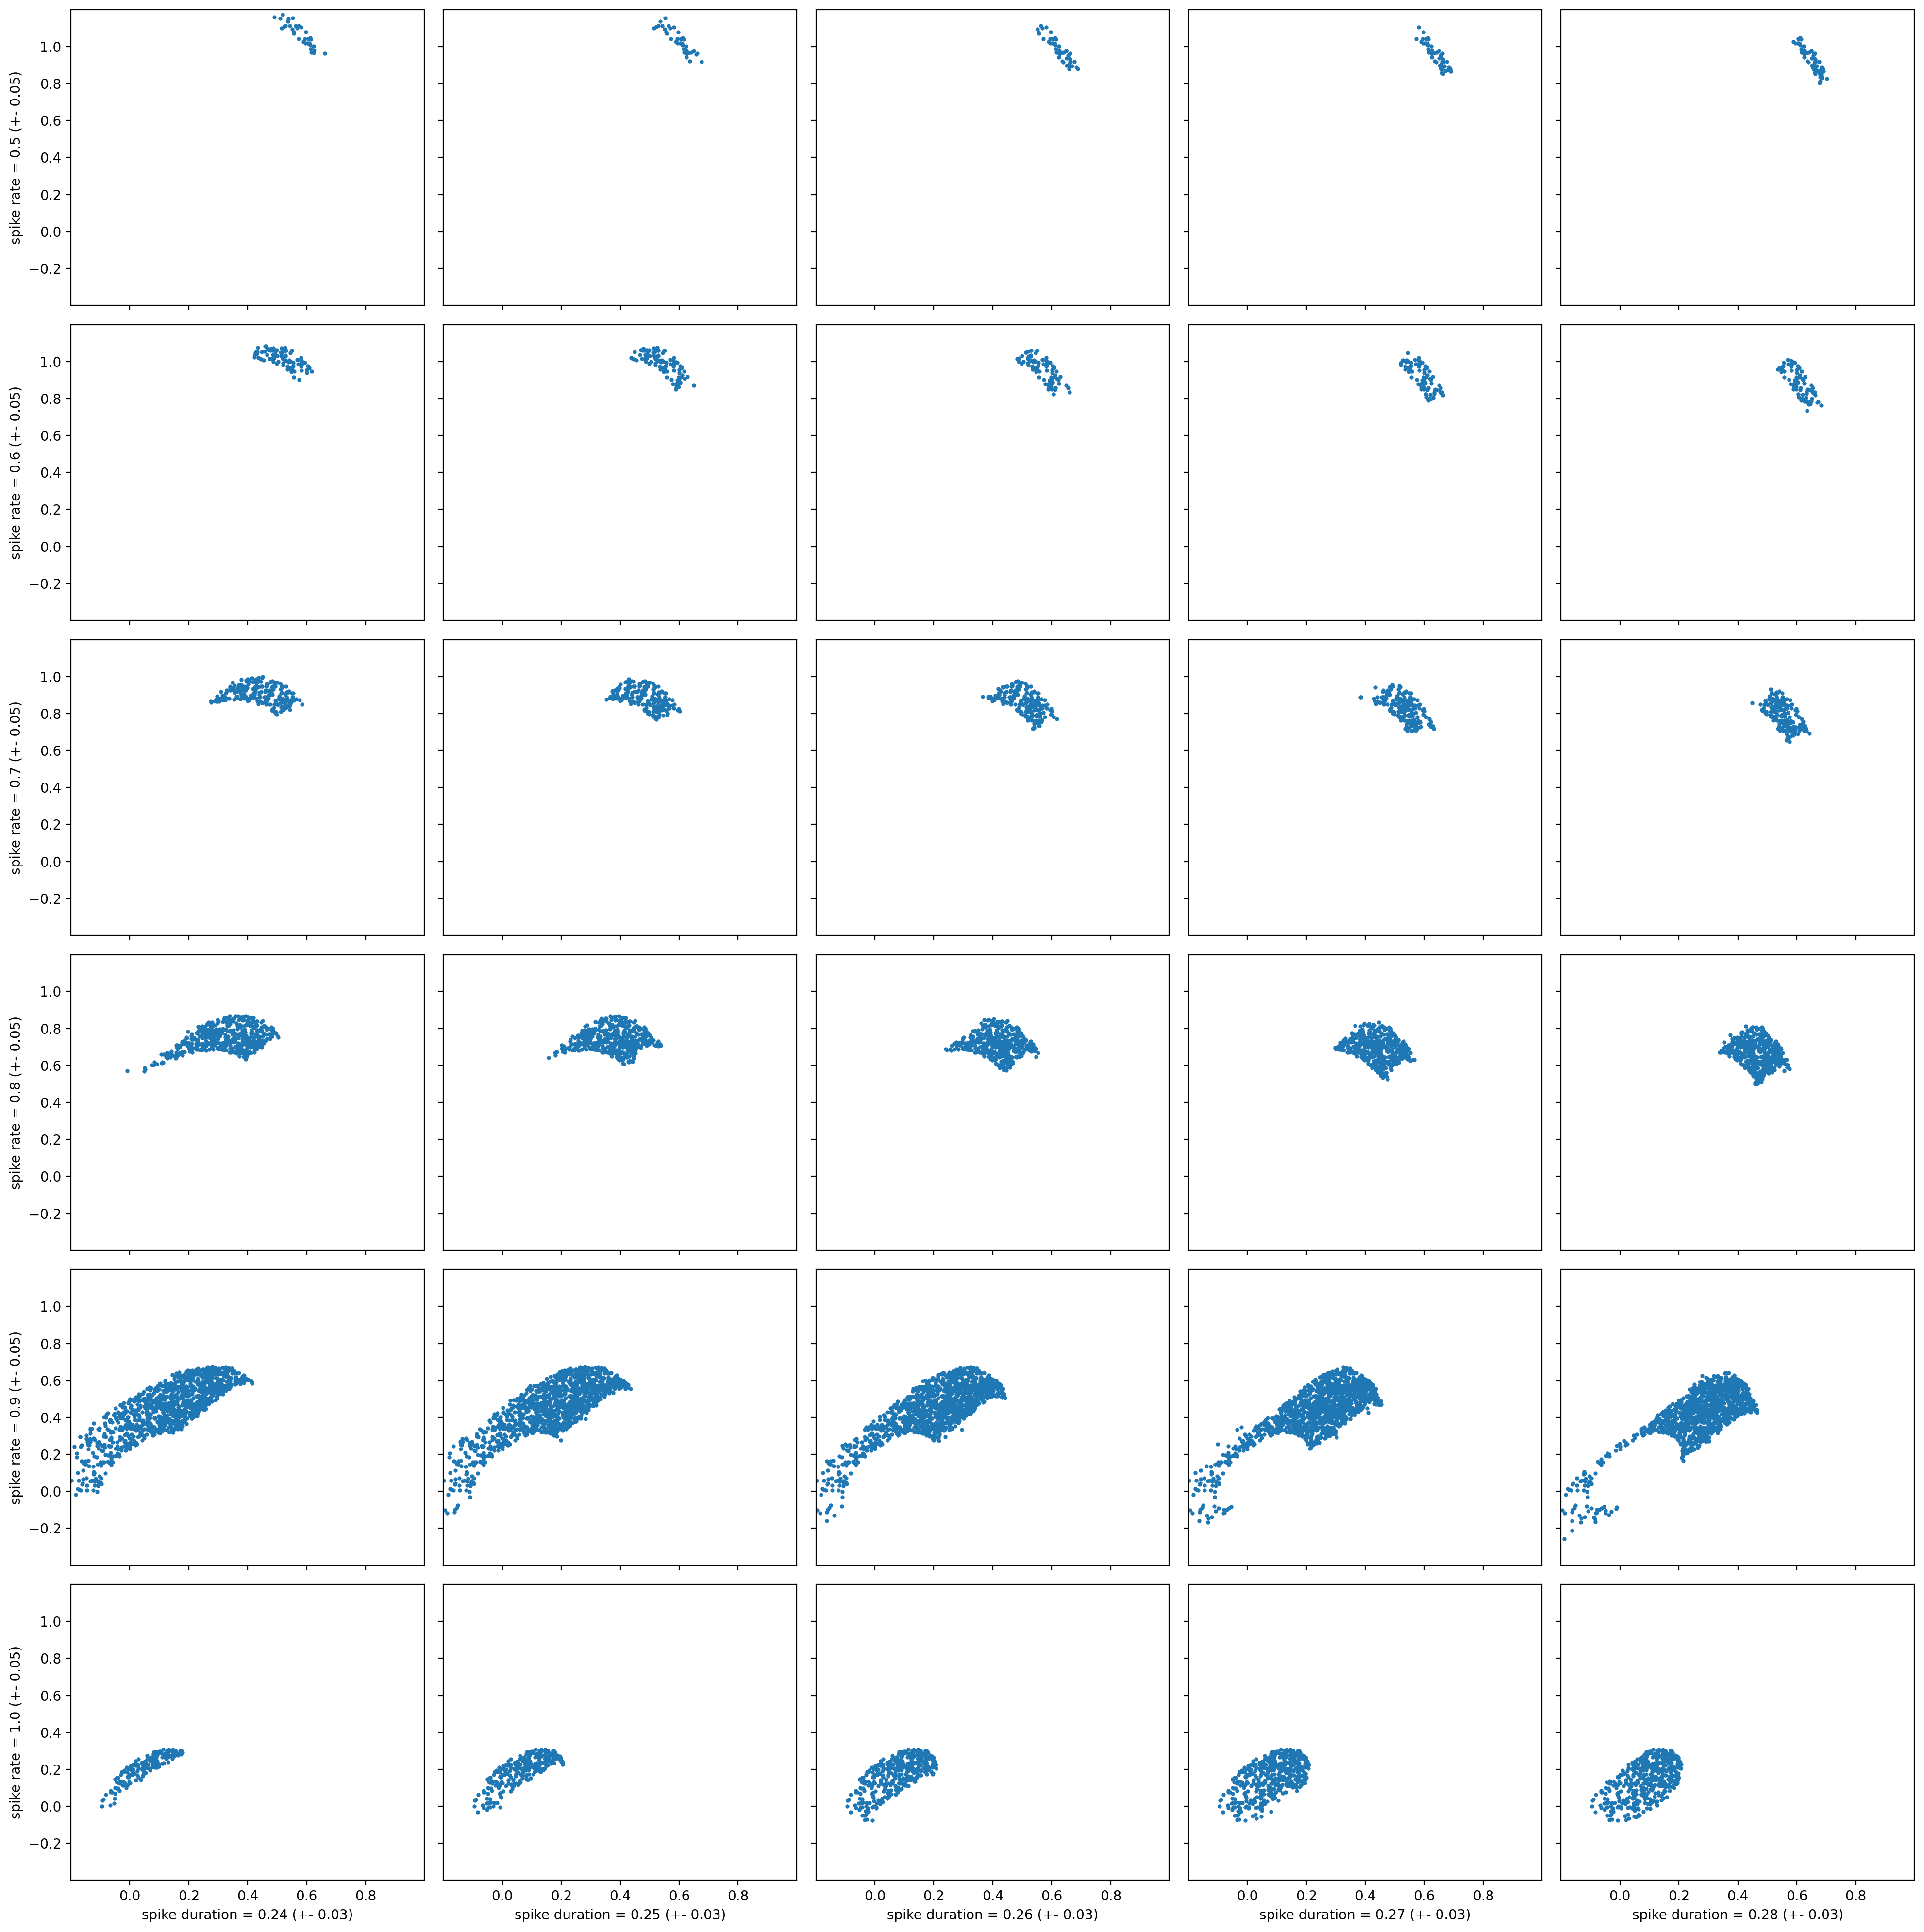

In [9]:
# create plots
fig, ax = plt.subplots(len(selected_values['spikeRate']), len(selected_values['spikeDuration']), figsize=(20, 20))

for i, sr in enumerate(selected_values['spikeRate']):
    for j, sd in enumerate(selected_values['spikeDuration']):
        features_thresh, targets_thresh = _filter_samples(
            features, targets,
            [sr, sd], [threshold['spikeRate'], threshold['spikeDuration']]
        )
        
        # plot points
        ax[i,j].scatter(targets_thresh[:,0], targets_thresh[:,1], s=2**2)
        ax[i,j].set_xlim(x_lim)
        ax[i,j].set_ylim(y_lim)
        if i+1 < len(selected_values['spikeRate']):
            ax[i,j].set_xticklabels([])
        else:
            ax[i,j].set_xlabel('spike duration = {:.3} (+- {:.4})'.format(sd, threshold['spikeDuration']))
        if 0 < j:
            ax[i,j].set_yticklabels([])
        else:
            ax[i,j].set_ylabel('spike rate = {:.3} (+- {:.4})'.format(sr, threshold['spikeRate']))

fig.tight_layout()
plt.show()

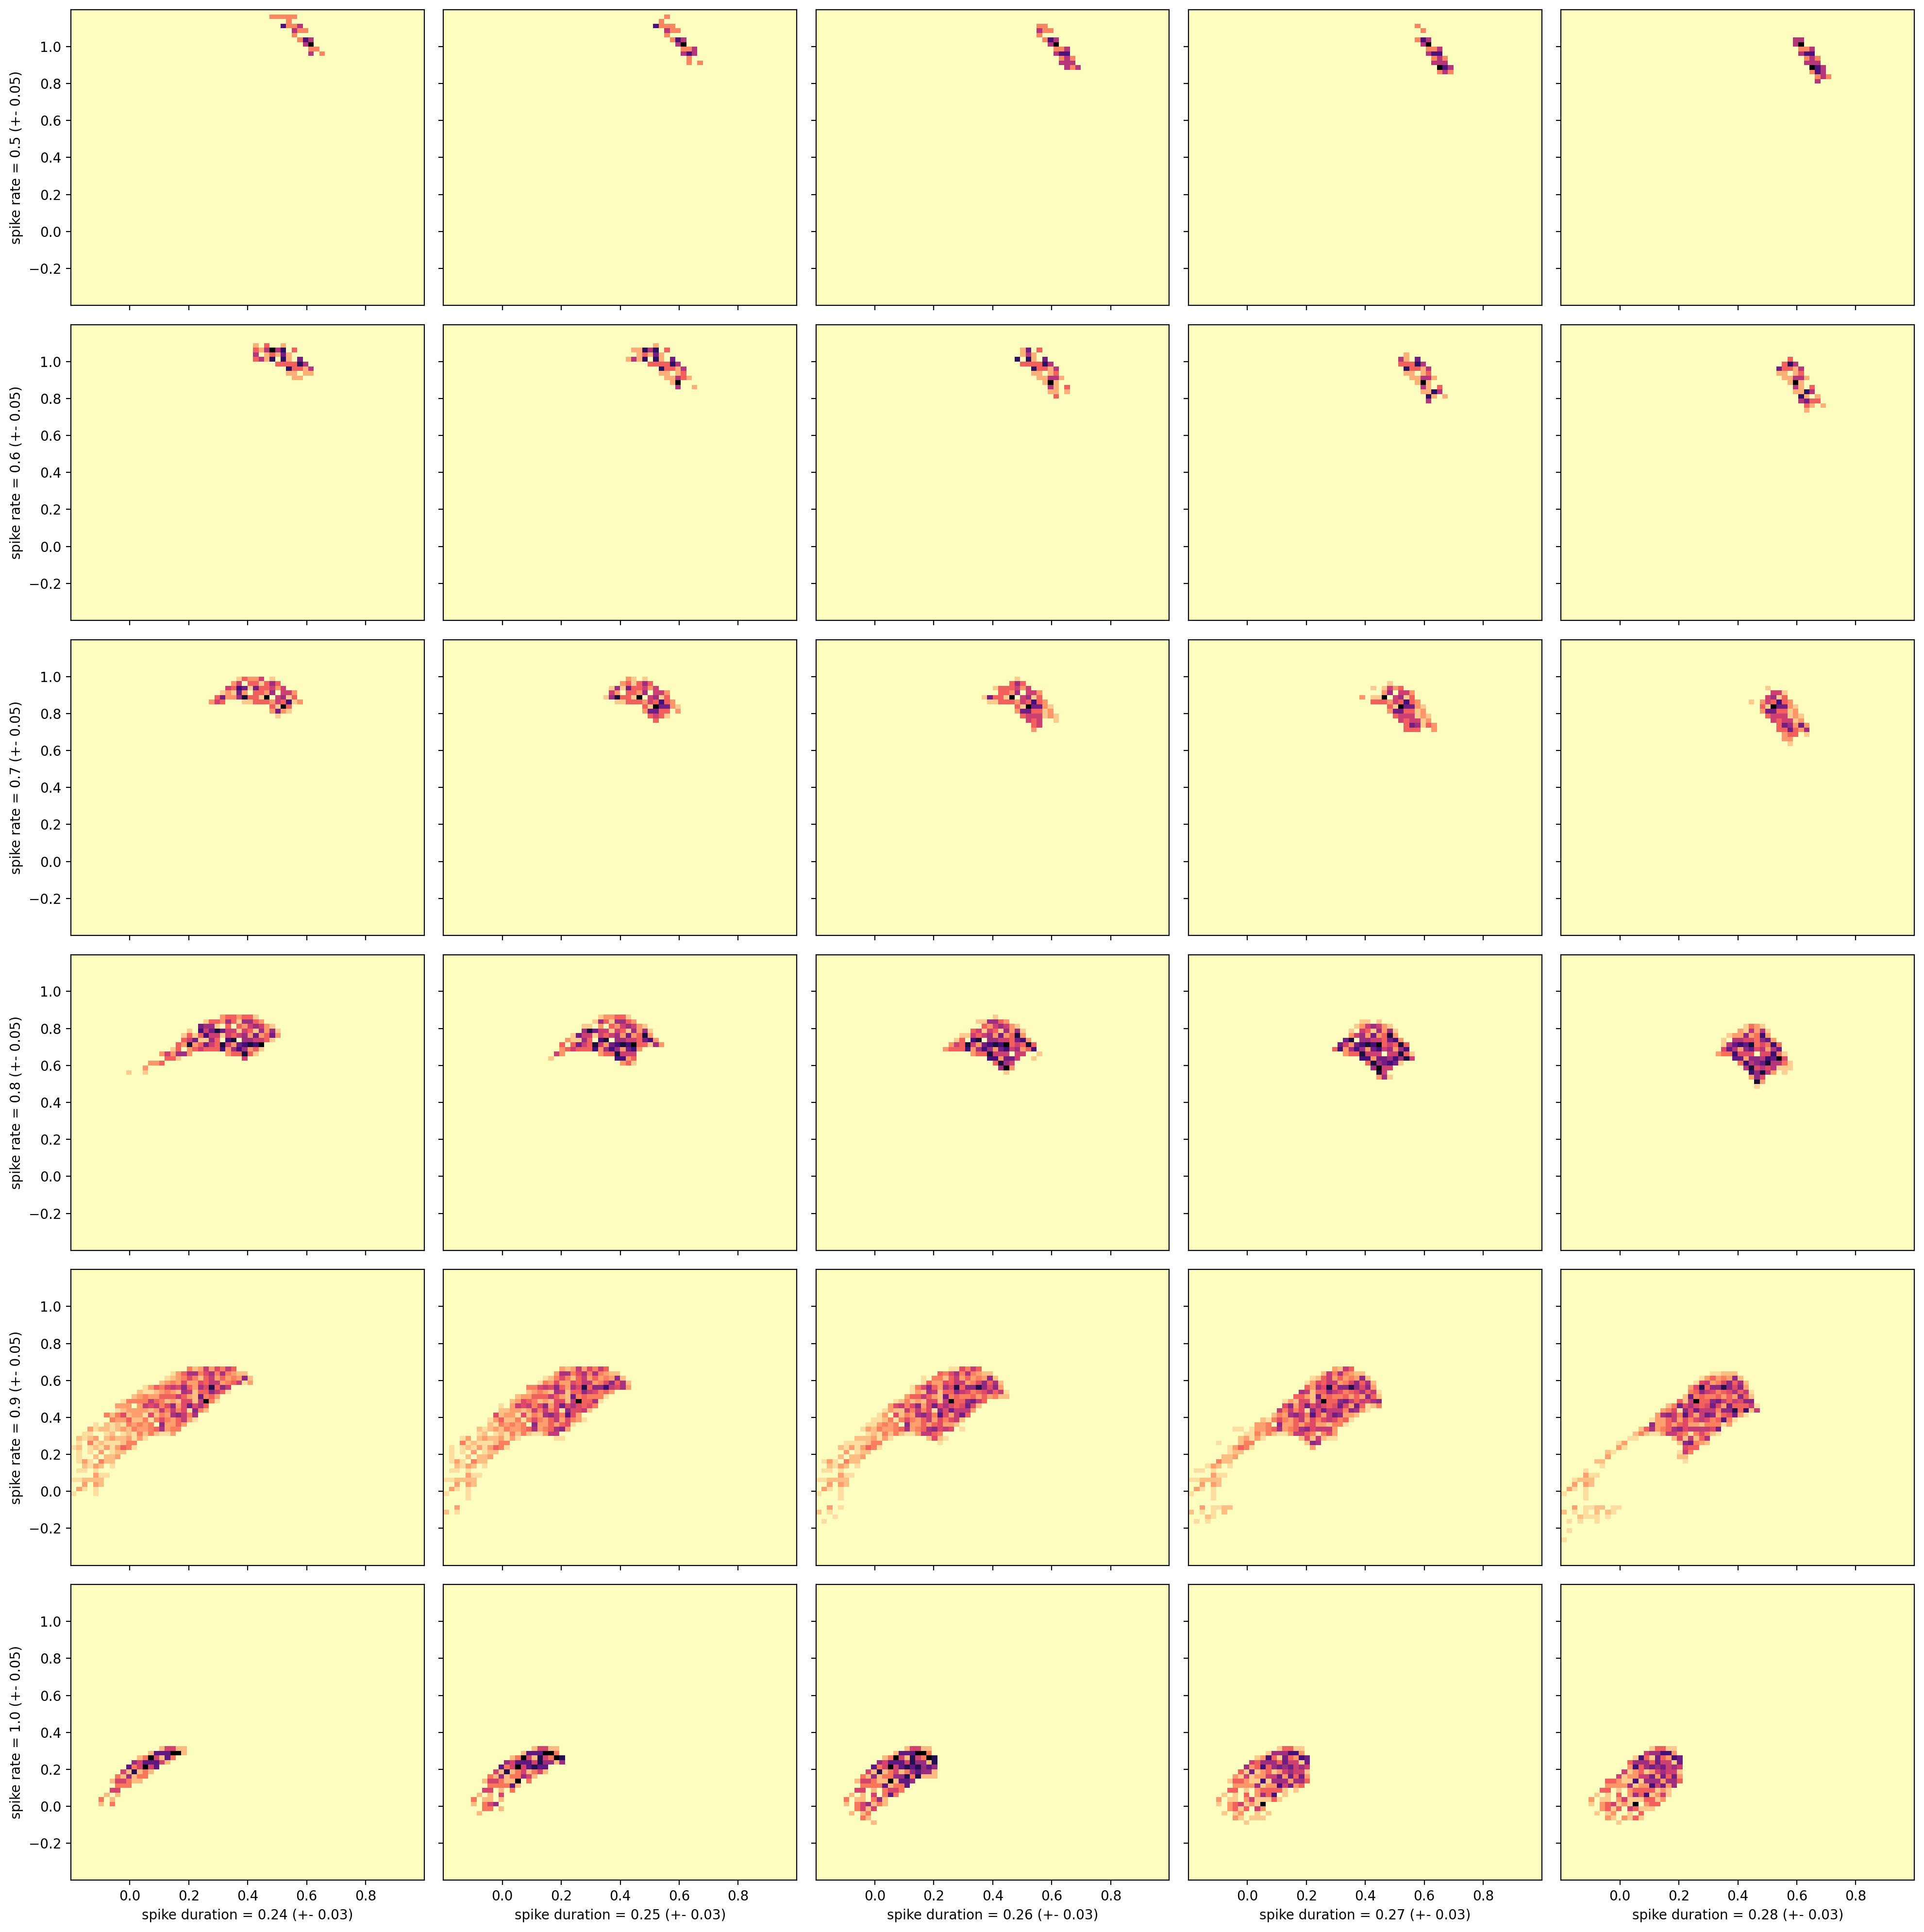

In [10]:
# create plots
fig, ax = plt.subplots(len(selected_values['spikeRate']), len(selected_values['spikeDuration']), figsize=(20, 20))

for i, sr in enumerate(selected_values['spikeRate']):
    for j, sd in enumerate(selected_values['spikeDuration']):
        features_thresh, targets_thresh = _filter_samples(
            features, targets,
            [sr, sd], [threshold['spikeRate'], threshold['spikeDuration']]
        )
        
        # plot points
        ax[i,j].hist2d(targets_thresh[:,0], targets_thresh[:,1], bins=64, cmap='magma_r', range=[x_lim, y_lim])
        if i+1 < len(selected_values['spikeRate']):
            ax[i,j].set_xticklabels([])
        else:
            ax[i,j].set_xlabel('spike duration = {:.3} (+- {:.4})'.format(sd, threshold['spikeDuration']))
        if 0 < j:
            ax[i,j].set_yticklabels([])
        else:
            ax[i,j].set_ylabel('spike rate = {:.3} (+- {:.4})'.format(sr, threshold['spikeRate']))

fig.tight_layout()
plt.show()